# Library + RUONIA 1M Hybrid

Этот ноутбук берет максимально возможное из `pyacm`:
- PCA factors
- VAR(1)
- excess-return regression
- `lambda0`, `lambda1`

И затем заменяет только short-rate layer:
- оценивает `delta0`, `delta1` на `RUONIA 1M`
- пересчитывает affine coefficients
- строит `fitted`, `risk-neutral` и `term premium`

Тем самым можно изолированно проверить: портит ли результат именно short-rate proxy.


In [1]:
from pathlib import Path
import re

import numpy as np
import pandas as pd
from pyacm import NominalACM

from build_moex_curve import build_moex_curve
from ruonia import load_ruonia_1m, build_ruonia_monthly
from visualizations import plot_term_premium_comparison, plot_term_premium_decomposition


In [2]:
def tenor_columns(df: pd.DataFrame) -> list[str]:
    return sorted(
        [c for c in df.columns if re.fullmatch(r"M\d{3}", c)],
        key=lambda c: int(c[1:]),
    )


def to_pyacm_curve(curve_df: pd.DataFrame) -> pd.DataFrame:
    df = curve_df.copy()
    df["date"] = pd.to_datetime(df["month_end"])
    df = df.set_index("date").sort_index()

    cols = tenor_columns(df)
    yield_curve = df[cols].copy()
    yield_curve.columns = [int(c[1:]) for c in cols]
    yield_curve = np.log1p(yield_curve / 100.0)

    yield_curve.index.name = "date"
    yield_curve.columns.name = "maturity_months"
    return yield_curve


def make_library_scores(acm: NominalACM) -> pd.DataFrame:
    scores = acm.pc_factors_m.reset_index().rename(
        columns={
            "date": "month_end",
            "PC 1": "PC1",
            "PC 2": "PC2",
            "PC 3": "PC3",
        }
    )
    scores["month_end"] = pd.to_datetime(scores["month_end"])
    scores["month"] = scores["month_end"].dt.to_period("M").astype(str)
    return scores[["month", "month_end", "PC1", "PC2", "PC3"]].copy()


def fit_short_rate_ruonia(scores_df: pd.DataFrame, ruonia_monthly: pd.DataFrame):
    merged = scores_df.merge(
        ruonia_monthly[["month", "month_end", "short_rate_monthly_cc"]],
        on=["month", "month_end"],
        how="inner",
    )
    if merged.empty:
        raise ValueError("No overlap between library factors and RUONIA monthly series")

    x = np.column_stack([np.ones(len(merged)), merged[["PC1", "PC2", "PC3"]].to_numpy(dtype=float)])
    y = merged["short_rate_monthly_cc"].to_numpy(dtype=float)
    coef, _, _, _ = np.linalg.lstsq(x, y, rcond=None)
    fitted = x @ coef
    residuals = y - fitted

    params = pd.DataFrame(
        {
            "parameter": ["delta0", "delta1_PC1", "delta1_PC2", "delta1_PC3", "sigma2"],
            "value": [float(coef[0]), float(coef[1]), float(coef[2]), float(coef[3]), float(np.var(residuals, ddof=0))],
        }
    )
    return float(coef[0]), coef[1:].astype(float), merged, params


def build_library_term_premium_frame(acm: NominalACM) -> pd.DataFrame:
    months = list(acm.curve.columns)
    arrays = {"date": acm.curve.index}
    for month in months:
        arrays[f"obs_M{month:03d}"] = acm.curve[month].to_numpy(dtype=float) * 100.0
        arrays[f"fit_M{month:03d}"] = acm.miy[month].to_numpy(dtype=float) * 100.0
        arrays[f"rn_M{month:03d}"] = acm.rny[month].to_numpy(dtype=float) * 100.0
        arrays[f"tp_M{month:03d}"] = acm.tp[month].to_numpy(dtype=float) * 100.0
    return pd.DataFrame(arrays)


def build_hybrid_term_premium(acm: NominalACM, delta0: float, delta1: np.ndarray) -> pd.DataFrame:
    months = list(acm.curve.columns)
    n = len(months)

    a_fit = np.zeros(n)
    b_fit = np.zeros((n, acm.n_factors))
    a_rn = np.zeros(n)
    b_rn = np.zeros((n, acm.n_factors))

    a_fit[0] = -delta0
    b_fit[0, :] = -delta1
    a_rn[0] = -delta0
    b_rn[0, :] = -delta1

    mu = np.asarray(acm.mu).reshape(-1, 1)
    phi = np.asarray(acm.phi)
    lambda0 = np.asarray(acm.lambda0).reshape(-1, 1)
    lambda1 = np.asarray(acm.lambda1)
    s0 = np.asarray(acm.s0).reshape(-1, 1)
    omega_scalar = float(acm.omega[0, 0])

    for idx in range(1, n):
        prev_fit = b_fit[idx - 1, :]
        prev_rn = b_rn[idx - 1, :]

        s0term_fit = 0.5 * (np.kron(prev_fit, prev_fit) @ s0 + omega_scalar)
        s0term_rn = 0.5 * (np.kron(prev_rn, prev_rn) @ s0 + omega_scalar)

        a_fit[idx] = float(a_fit[idx - 1] + prev_fit @ (mu - lambda0)[:, 0] + s0term_fit + a_fit[0])
        b_fit[idx, :] = prev_fit @ (phi - lambda1) + b_fit[0, :]

        a_rn[idx] = float(a_rn[idx - 1] + prev_rn @ mu[:, 0] + s0term_rn + a_rn[0])
        b_rn[idx, :] = prev_rn @ phi + b_rn[0, :]

    factors_d = acm.pc_factors_d.rename(
        columns={"PC 1": "PC1", "PC 2": "PC2", "PC 3": "PC3"}
    )[["PC1", "PC2", "PC3"]].to_numpy(dtype=float)

    arrays = {"date": acm.curve.index}
    for idx, month in enumerate(months):
        tau = month / 12.0
        fit = -((a_fit[idx] + factors_d @ b_fit[idx, :]) / tau)
        rn = -((a_rn[idx] + factors_d @ b_rn[idx, :]) / tau)
        obs = acm.curve[month].to_numpy(dtype=float)

        arrays[f"obs_M{month:03d}"] = obs * 100.0
        arrays[f"fit_M{month:03d}"] = fit * 100.0
        arrays[f"rn_M{month:03d}"] = rn * 100.0
        arrays[f"tp_M{month:03d}"] = (fit - rn) * 100.0

    return pd.DataFrame(arrays)


In [3]:
CLEAN_DIR = Path('.')
DEFAULT_DYNAMIC_PATH = CLEAN_DIR / 'data' / 'dynamic.csv'
DEFAULT_DAILY_OUTPUT = CLEAN_DIR / 'output' / 'moex_curve_daily.csv'
DEFAULT_MONTHLY_OUTPUT = CLEAN_DIR / 'output' / 'moex_curve_monthly.csv'
RUONIA_1M_PATH = CLEAN_DIR / 'data' / 'ruonia_1M.csv'

months = list(range(1, 181))

_, all_monthly_curve = build_moex_curve(
    dynamic_path=DEFAULT_DYNAMIC_PATH,
    daily_output_path=DEFAULT_DAILY_OUTPUT,
    monthly_output_path=DEFAULT_MONTHLY_OUTPUT,
    months=months,
)

ruonia_monthly = build_ruonia_monthly(load_ruonia_1m(RUONIA_1M_PATH))
yield_curve = to_pyacm_curve(all_monthly_curve)
acm = NominalACM(curve=yield_curve, n_factors=3)

scores = make_library_scores(acm)
library_tp = build_library_term_premium_frame(acm)
delta0_ruonia, delta1_ruonia, short_rate_sample, short_rate_params = fit_short_rate_ruonia(scores, ruonia_monthly)
hybrid_tp = build_hybrid_term_premium(acm=acm, delta0=delta0_ruonia, delta1=delta1_ruonia)

short_rate_params


/Users/codebuller/Desktop/term_rate/.venv/lib/python3.9/site-packages/pyacm/acm.py:155: FutureWarning: 'M' is deprecated and will be removed in a future version, please use 'ME' instead.
  self.curve_monthly = curve.resample('M').mean()
/var/folders/cj/d68fmsfj3jj2j09286d43rth0000gn/T/ipykernel_16259/1023967059.py:100: DeprecationWarning: Conversion of an array with ndim > 0 to a scalar is deprecated, and will error in future. Ensure you extract a single element from your array before performing this operation. (Deprecated NumPy 1.25.)
  a_fit[idx] = float(a_fit[idx - 1] + prev_fit @ (mu - lambda0)[:, 0] + s0term_fit + a_fit[0])
/var/folders/cj/d68fmsfj3jj2j09286d43rth0000gn/T/ipykernel_16259/1023967059.py:103: DeprecationWarning: Conversion of an array with ndim > 0 to a scalar is deprecated, and will error in future. Ensure you extract a single element from your array before performing this operation. (Deprecated NumPy 1.25.)
  a_rn[idx] = float(a_rn[idx - 1] + prev_rn @ mu[:, 0] + s

,parameter,value
0,delta0,8.094837e-03
1,delta1_PC1,3.205914e-03
2,delta1_PC2,-7.220208e-04
3,delta1_PC3,5.366336e-04
4,sigma2,8.199855e-07


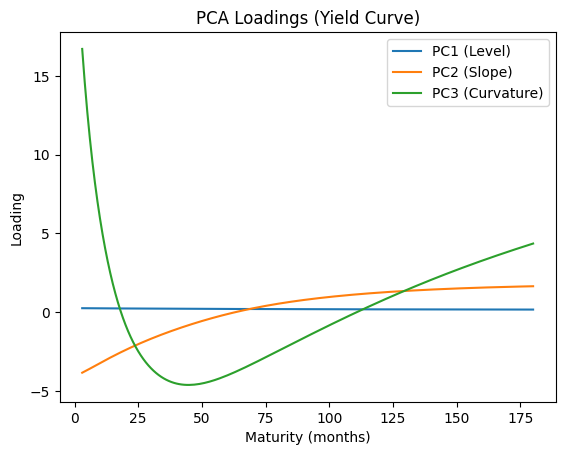

In [4]:
# acm.pc_loadings_m.index
import matplotlib.pyplot as plt
tenors = acm.pc_loadings_m.index

plt.figure()
plt.plot(tenors, acm.pc_loadings_m['PC 1'])
plt.plot(tenors, acm.pc_loadings_m['PC 2'])
plt.plot(tenors, acm.pc_loadings_m['PC 3'])

plt.xlabel('Maturity (months)')
plt.ylabel('Loading')
plt.title('PCA Loadings (Yield Curve)')
plt.legend(['PC1 (Level)', 'PC2 (Slope)', 'PC3 (Curvature)'])
plt.show()

In [5]:
comparison_last = pd.DataFrame(
    {
        'version': ['library_curve_short', 'hybrid_ruonia_short'],
        'tp_24_last_pct': [library_tp['tp_M024'].iloc[-1], hybrid_tp['tp_M024'].iloc[-1]],
        'tp_60_last_pct': [library_tp['tp_M060'].iloc[-1], hybrid_tp['tp_M060'].iloc[-1]],
        'tp_120_last_pct': [library_tp['tp_M120'].iloc[-1], hybrid_tp['tp_M120'].iloc[-1]],
        'tp_180_last_pct': [library_tp['tp_M180'].iloc[-1], hybrid_tp['tp_M180'].iloc[-1]],
    }
)
comparison_last


,version,tp_24_last_pct,tp_60_last_pct,tp_120_last_pct,tp_180_last_pct
0,library_curve_short,-0.306465,0.524048,1.535636,2.230948
1,hybrid_ruonia_short,-0.241942,0.644755,1.746972,2.462106


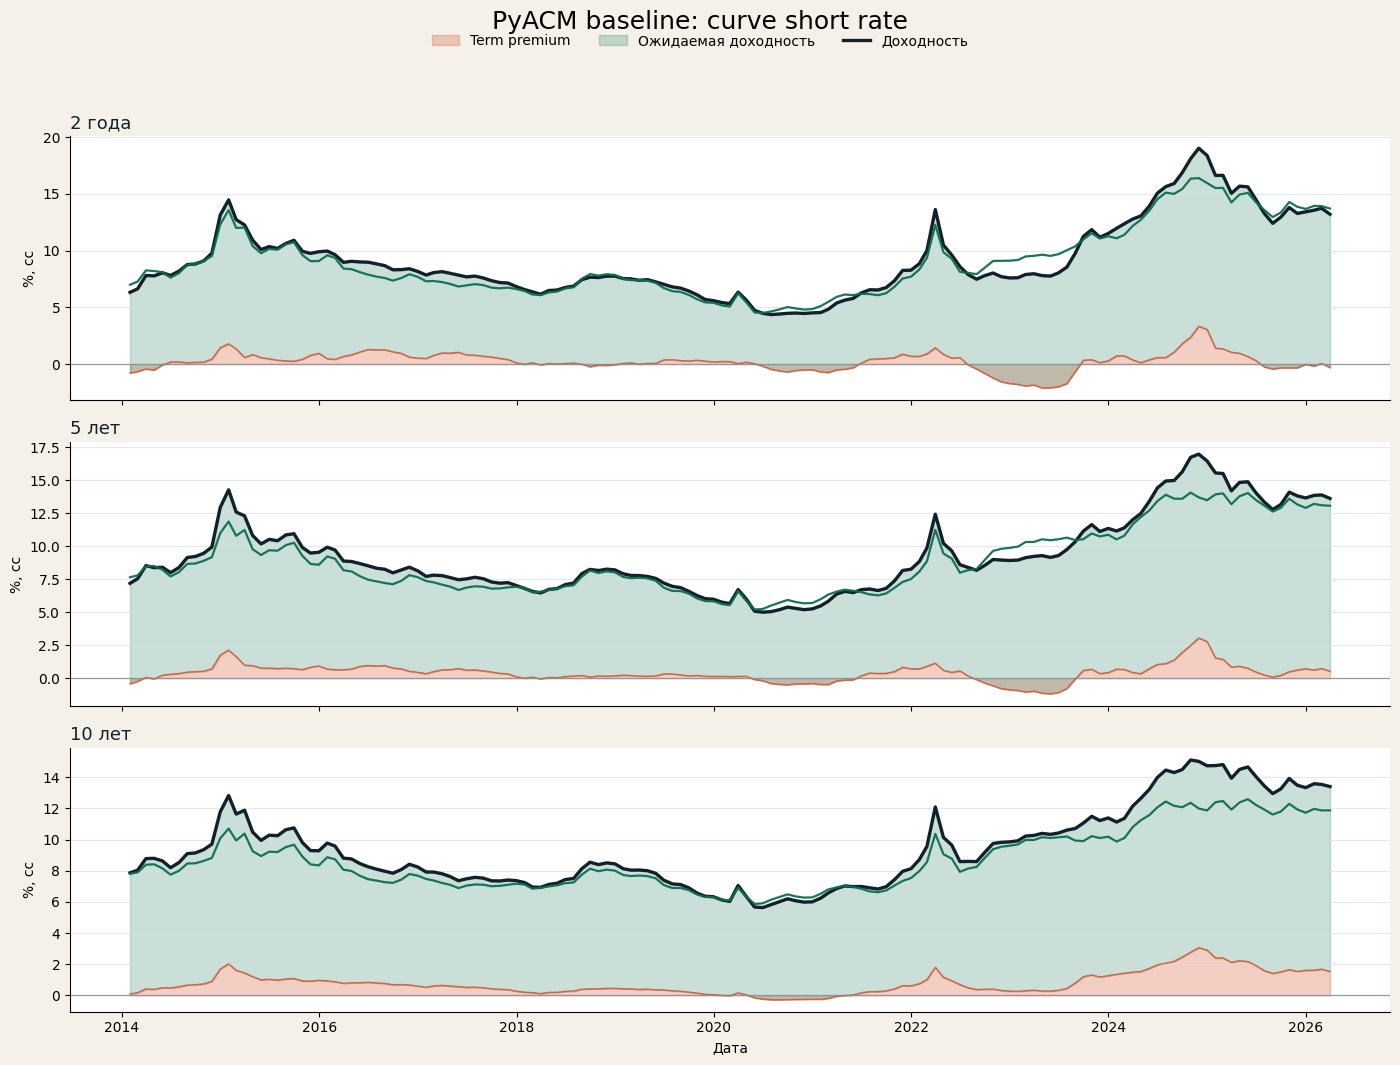

In [6]:
fig, axes = plot_term_premium_decomposition(
    term_premium_df=library_tp,
    tenors={24: '2 года', 60: '5 лет', 120: '10 лет'},
    title='PyACM baseline: curve short rate',
)


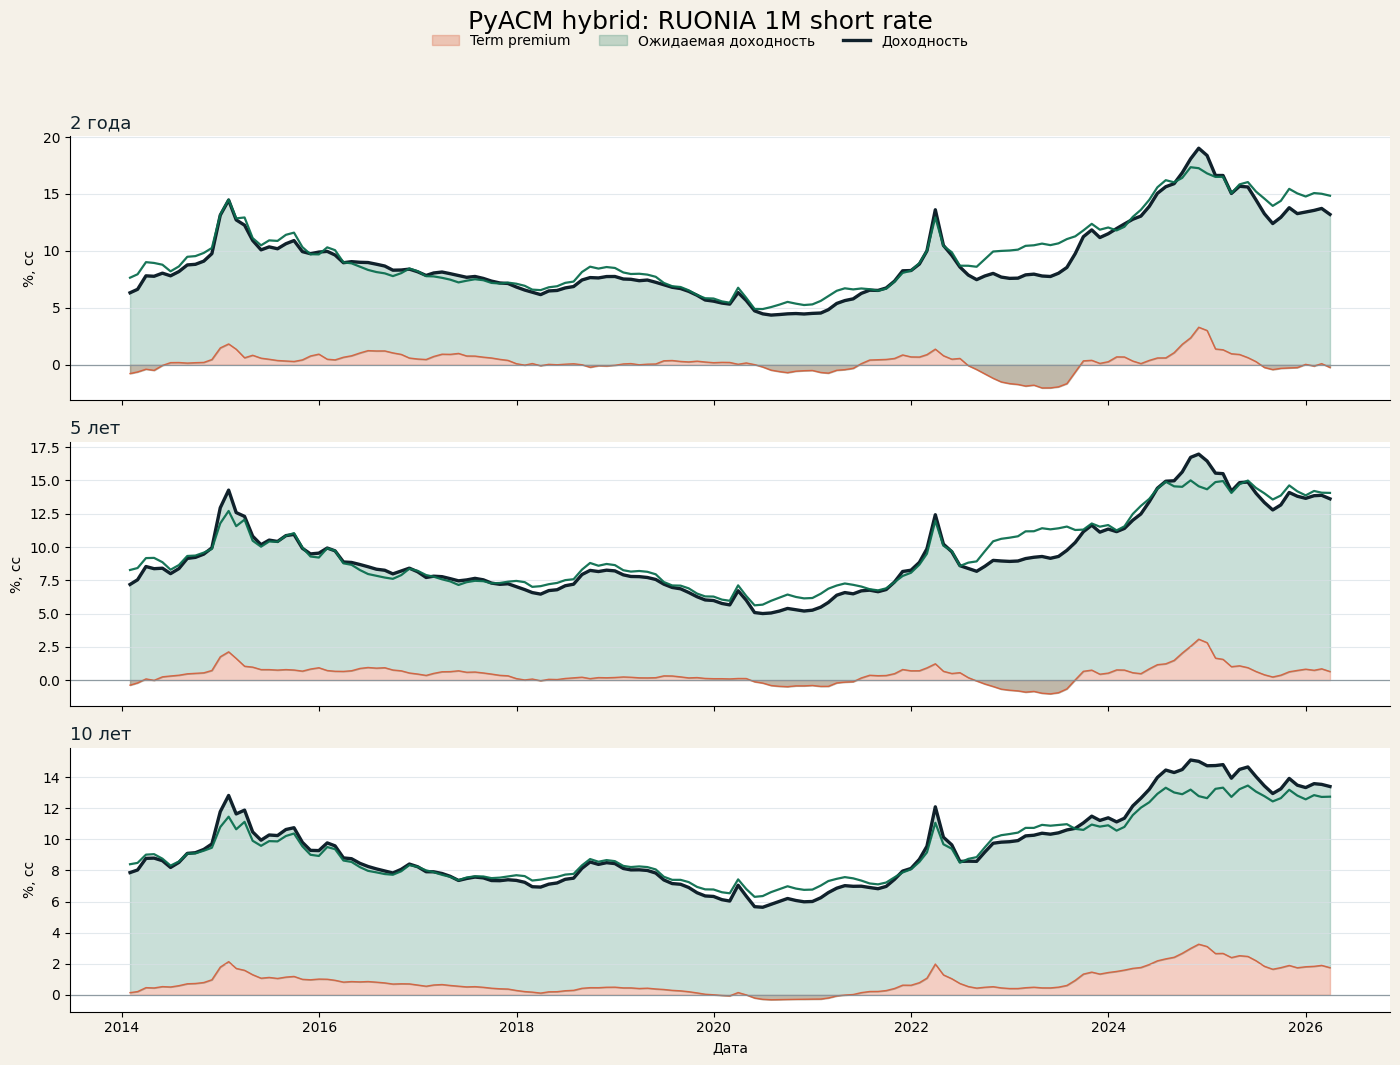

In [7]:
fig, axes = plot_term_premium_decomposition(
    term_premium_df=hybrid_tp,
    tenors={24: '2 года', 60: '5 лет', 120: '10 лет'},
    title='PyACM hybrid: RUONIA 1M short rate',
)


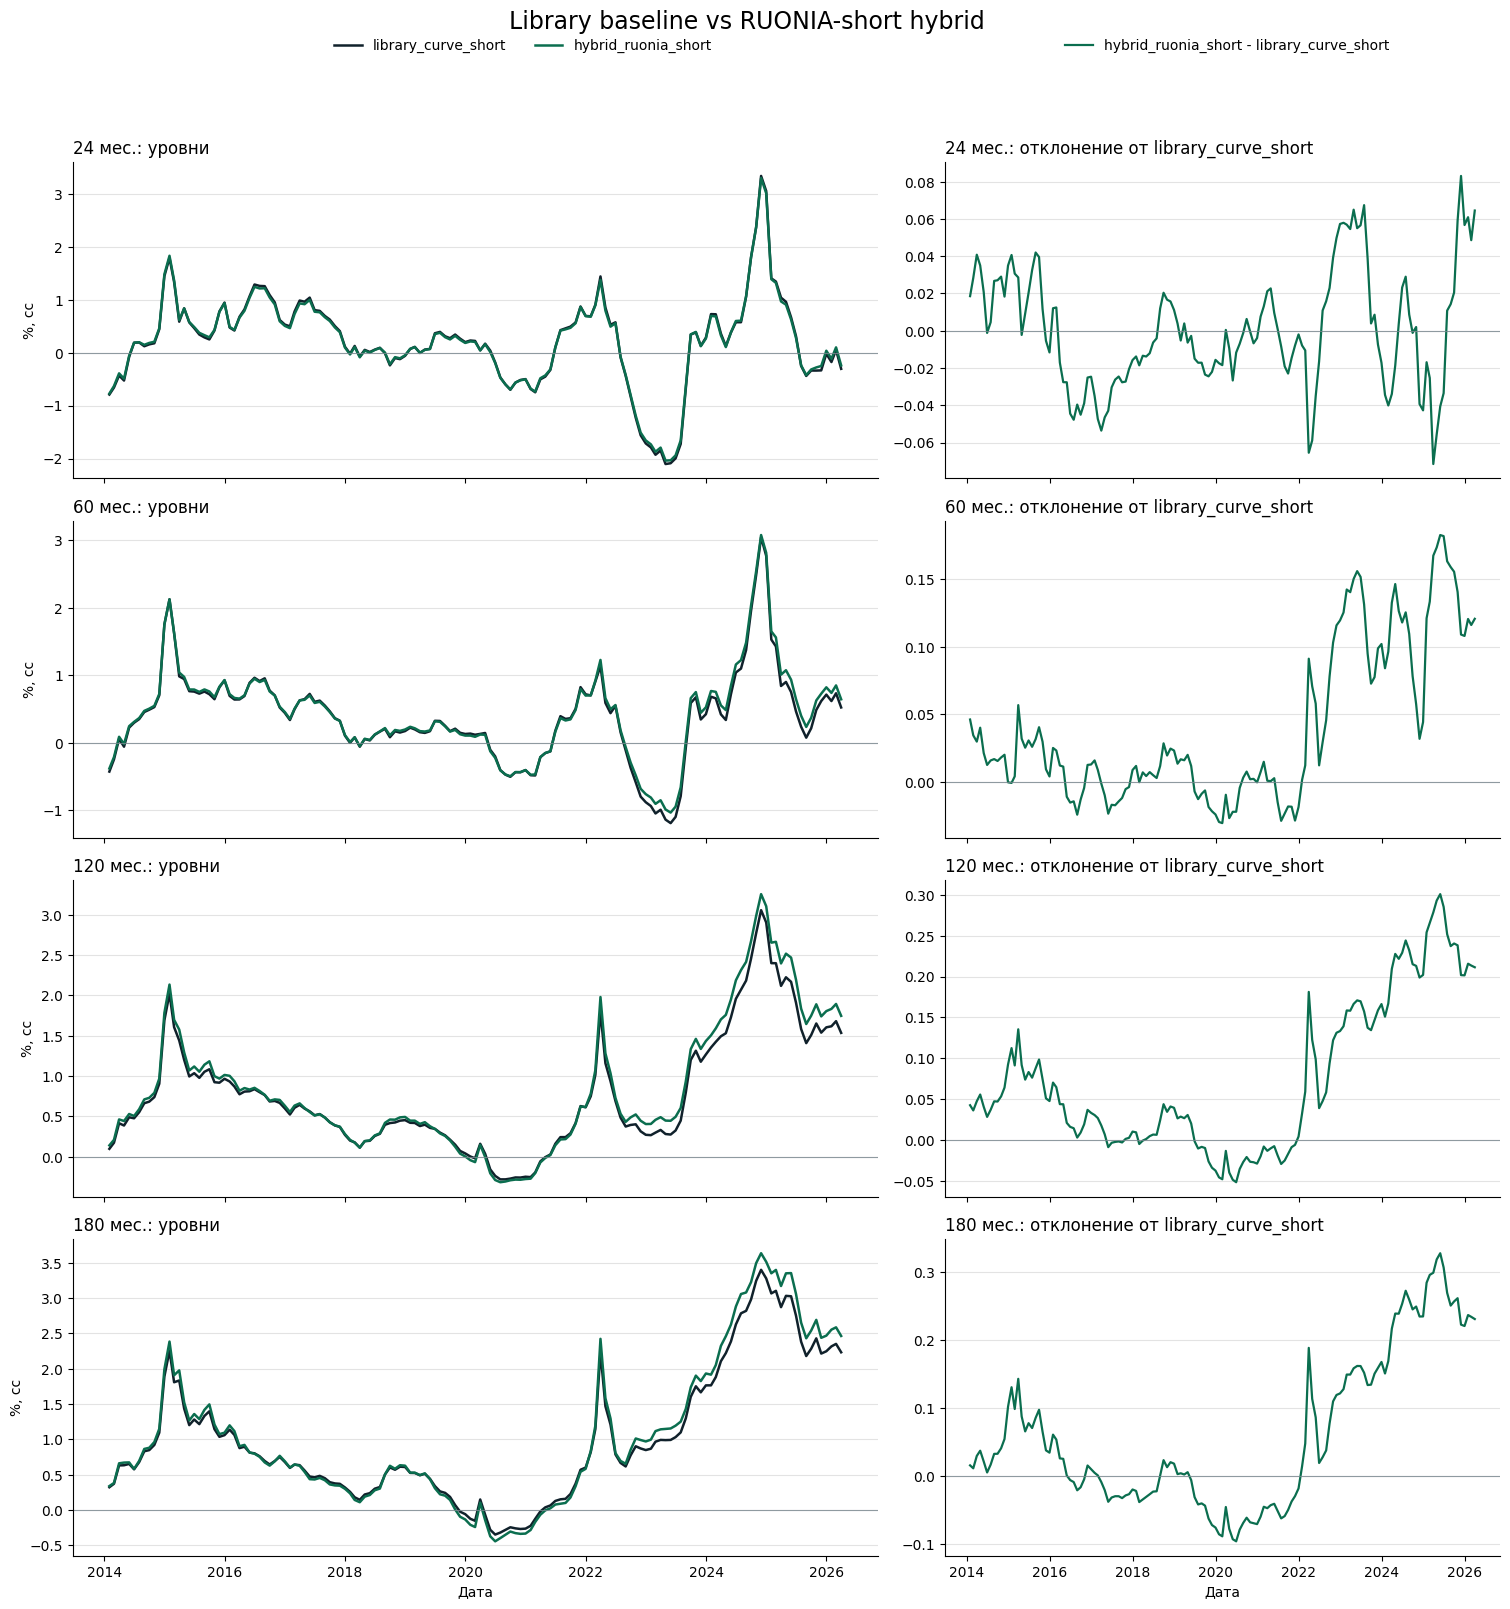

In [8]:
fig, axes = plot_term_premium_comparison(
    versions={
        'library_curve_short': library_tp,
        'hybrid_ruonia_short': hybrid_tp,
    },
    baseline='library_curve_short',
    tenors=(24, 60, 120, 180),
    title='Library baseline vs RUONIA-short hybrid',
)


In [9]:
library_tp.to_csv('output/lib_term_premium_curve_short.csv', index=False)
hybrid_tp.to_csv('output/lib_term_premium_ruonia_short.csv', index=False)
short_rate_params.to_csv('output/lib_ruonia_short_rate_params.csv', index=False)

library_tp[['date', 'tp_M024', 'tp_M060', 'tp_M120', 'tp_M180']].tail()


,date,tp_M024,tp_M060,tp_M120,tp_M180
142,2025-11-30,-0.335667,0.618611,1.538745,2.212718
143,2025-12-31,-0.021278,0.714064,1.604457,2.245746
144,2026-01-31,-0.178114,0.618863,1.617634,2.314664
145,2026-02-28,0.050264,0.734154,1.680993,2.349935
146,2026-03-31,-0.306465,0.524048,1.535636,2.230948


## Наблюдаемые детерминанты из записки ЦБ

Здесь мы берем базовую спецификацию из записки ЦБ и регрессируем `TP 2Y / 5Y / 10Y` на наблюдаемые факторы:
- `CPI_mmSA(t-1)`
- `CPI_exp`
- `USD_vol(t-1)`

Важно: `CPI_mmSA` здесь построен как приближение через STL-сезонную корректировку официального месячного ИПЦ Росстата, а `USD_vol` считается как стандартное отклонение биржевого курса `USD/RUB TOM` в течение месяца.


In [10]:
from cbr_determinants import build_cbr_observed_factors, run_tp_determinant_regressions

observed_factors = build_cbr_observed_factors()
observed_factors.tail(12)


,month_end,cpi_mm_pct_raw,cpi_mmsa_pct,cpi_exp_pct,usd_vol,cpi_mmsa_lag1,usd_vol_lag1
411,2025-04-30,0.40,0.636717,13.1019,NaN,0.789499,NaN
412,2025-05-31,0.43,0.547467,13.4000,NaN,0.636717,NaN
413,2025-06-30,0.20,0.466489,13.0497,NaN,0.547467,NaN
414,2025-07-31,0.57,0.346343,13.0479,NaN,0.466489,NaN
415,2025-08-31,-0.40,0.336641,13.4838,NaN,0.346343,NaN
416,2025-09-30,0.34,0.475222,12.6022,NaN,0.336641,NaN
417,2025-10-31,0.50,0.466084,12.6062,NaN,0.475222,NaN
418,2025-11-30,0.42,0.180501,13.2692,NaN,0.466084,NaN
419,2025-12-31,0.32,0.271631,13.6944,NaN,0.180501,NaN
420,2026-01-31,1.62,0.708174,13.6630,NaN,0.271631,NaN


In [11]:
library_det_results, library_det_sample = run_tp_determinant_regressions(library_tp, observed_factors)
library_det_results.insert(0, 'model', 'library')

hybrid_det_results, hybrid_det_sample = run_tp_determinant_regressions(hybrid_tp, observed_factors)
hybrid_det_results.insert(0, 'model', 'hybrid_ruonia')

determinant_results = pd.concat([library_det_results, hybrid_det_results], ignore_index=True)
determinant_results


,model,tenor_months,parameter,coef,std_err,t,p,r2,n_obs
0,library,24,const,-1.231846,0.265202,-4.644932,3.401885e-06,0.180904,122
1,library,24,cpi_mmsa_lag1,0.266350,0.103853,2.564686,1.032691e-02,0.180904,122
2,library,24,cpi_exp_pct,0.118582,0.021550,5.502704,3.740100e-08,0.180904,122
3,library,24,usd_vol_lag1,-0.138331,0.082667,-1.673356,9.425727e-02,0.180904,122
4,library,60,const,-1.209252,0.176017,-6.870101,6.415631e-12,0.356687,122
5,library,60,cpi_mmsa_lag1,0.229092,0.069500,3.296288,9.797164e-04,0.356687,122
6,library,60,cpi_exp_pct,0.129482,0.014463,8.952928,3.461758e-19,0.356687,122
7,library,60,usd_vol_lag1,-0.121105,0.050826,-2.382727,1.718491e-02,0.356687,122
8,library,120,const,-0.977900,0.126852,-7.708957,1.268501e-14,0.450800,122
9,library,120,cpi_mmsa_lag1,0.122212,0.058065,2.104744,3.531363e-02,0.450800,122


In [12]:
coef_table = determinant_results.pivot_table(index=['model', 'tenor_months'], columns='parameter', values='coef')
t_table = determinant_results.pivot_table(index=['model', 'tenor_months'], columns='parameter', values='t')

display(coef_table.round(4))
display(t_table.round(2))


parameter                    const  cpi_exp_pct  cpi_mmsa_lag1  usd_vol_lag1
model         tenor_months                                                  
hybrid_ruonia 24           -1.2496       0.1203         0.2655       -0.1400
              60           -1.2101       0.1312         0.2184       -0.1076
              120          -1.0527       0.1387         0.1185        0.0081
library       24           -1.2318       0.1186         0.2664       -0.1383
              60           -1.2093       0.1295         0.2291       -0.1211
              120          -0.9779       0.1290         0.1222       -0.0053

parameter                   const  cpi_exp_pct  cpi_mmsa_lag1  usd_vol_lag1
model         tenor_months                                                 
hybrid_ruonia 24            -4.88         5.80           2.66         -1.77
              60            -7.26         9.52           3.27         -2.23
              120           -7.56        10.98           1.85          0.19
library       24            -4.64         5.50           2.56         -1.67
              60            -6.87         8.95           3.30         -2.38
              120           -7.71        11.31           2.10         -0.14

In [13]:
observed_factors.to_csv('output/cbr_observed_factors.csv', index=False)
library_det_results.to_csv('output/lib_ruonia_determinants_library.csv', index=False)
hybrid_det_results.to_csv('output/lib_ruonia_determinants_hybrid.csv', index=False)

coef_table.round(4)


parameter                    const  cpi_exp_pct  cpi_mmsa_lag1  usd_vol_lag1
model         tenor_months                                                  
hybrid_ruonia 24           -1.2496       0.1203         0.2655       -0.1400
              60           -1.2101       0.1312         0.2184       -0.1076
              120          -1.0527       0.1387         0.1185        0.0081
library       24           -1.2318       0.1186         0.2664       -0.1383
              60           -1.2093       0.1295         0.2291       -0.1211
              120          -0.9779       0.1290         0.1222       -0.0053

## Визуализация детерминантов

Слева — коэффициенты регрессии по срокам `2Y / 5Y / 10Y`, справа — стандартизованные временные ряды факторов и `TP10Y`. Звездочкой отмечены коэффициенты с `p < 0.10`.


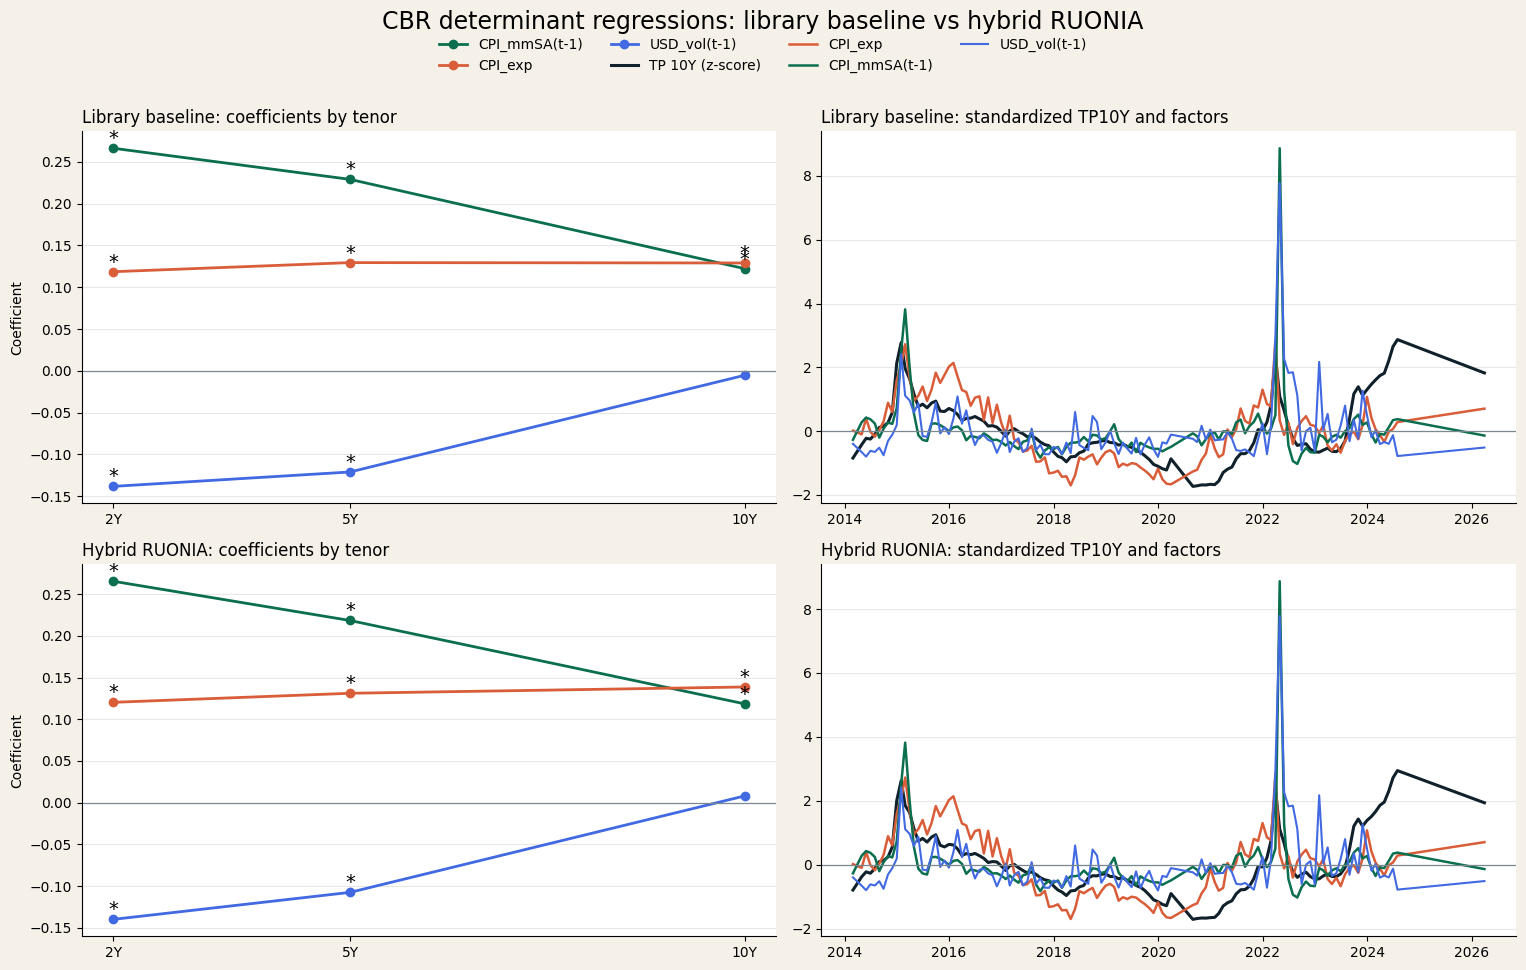

In [14]:
import matplotlib.pyplot as plt
import matplotlib.dates as mdates

factor_labels = {
    'cpi_mmsa_lag1': 'CPI_mmSA(t-1)',
    'cpi_exp_pct': 'CPI_exp',
    'usd_vol_lag1': 'USD_vol(t-1)',
}
factor_colors = {
    'cpi_mmsa_lag1': '#0b6e4f',
    'cpi_exp_pct': '#d95d39',
    'usd_vol_lag1': '#4169e1',
}
tenor_labels = {24: "2Y", 60: "5Y", 120: "10Y"}

fig, axes = plt.subplots(2, 2, figsize=(16, 10), facecolor="#f5f1e8")
model_specs = [
    ('library', library_det_sample, 'Library baseline'),
    ('hybrid_ruonia', hybrid_det_sample, 'Hybrid RUONIA'),
]

for row_idx, (model_name, sample_df, title) in enumerate(model_specs):
    coef_ax = axes[row_idx, 0]
    ts_ax = axes[row_idx, 1]

    subset = determinant_results[(determinant_results["model"] == model_name) & (determinant_results["parameter"] != "const")].copy()
    for parameter, label in factor_labels.items():
        tmp = subset[subset["parameter"] == parameter].sort_values("tenor_months")
        coef_ax.plot(tmp["tenor_months"], tmp["coef"], marker="o", lw=2, color=factor_colors[parameter], label=label)
        for _, obs in tmp.iterrows():
            if obs["p"] < 0.10:
                coef_ax.text(obs["tenor_months"], obs["coef"], "*", fontsize=14, ha="center", va="bottom")

    coef_ax.axhline(0.0, color="#7a8890", lw=0.9)
    coef_ax.set_xticks([24, 60, 120])
    coef_ax.set_xticklabels([tenor_labels[x] for x in [24, 60, 120]])
    coef_ax.set_title(f"{title}: coefficients by tenor", loc="left")
    coef_ax.set_ylabel("Coefficient")
    coef_ax.grid(True, axis="y", alpha=0.3)
    coef_ax.spines["top"].set_visible(False)
    coef_ax.spines["right"].set_visible(False)

    std_frame = sample_df[["month_end", "tp_M120", "cpi_exp_pct", "cpi_mmsa_lag1", "usd_vol_lag1"]].copy()
    for column in ["tp_M120", "cpi_exp_pct", "cpi_mmsa_lag1", "usd_vol_lag1"]:
        std = std_frame[column].std(ddof=0)
        if std == 0 or pd.isna(std):
            std_frame[column] = 0.0
        else:
            std_frame[column] = (std_frame[column] - std_frame[column].mean()) / std

    ts_ax.plot(std_frame["month_end"], std_frame["tp_M120"], color="#10212b", lw=2.2, label="TP 10Y (z-score)")
    ts_ax.plot(std_frame["month_end"], std_frame["cpi_exp_pct"], color=factor_colors["cpi_exp_pct"], lw=1.8, label="CPI_exp")
    ts_ax.plot(std_frame["month_end"], std_frame["cpi_mmsa_lag1"], color=factor_colors["cpi_mmsa_lag1"], lw=1.8, label="CPI_mmSA(t-1)")
    ts_ax.plot(std_frame["month_end"], std_frame["usd_vol_lag1"], color=factor_colors["usd_vol_lag1"], lw=1.5, label="USD_vol(t-1)")
    ts_ax.axhline(0.0, color="#7a8890", lw=0.9)
    ts_ax.set_title(f"{title}: standardized TP10Y and factors", loc="left")
    ts_ax.grid(True, axis="y", alpha=0.3)
    ts_ax.spines["top"].set_visible(False)
    ts_ax.spines["right"].set_visible(False)
    ts_ax.xaxis.set_major_locator(mdates.YearLocator(2))
    ts_ax.xaxis.set_major_formatter(mdates.DateFormatter("%Y"))

handles, labels = axes[0, 0].get_legend_handles_labels()
handles2, labels2 = axes[0, 1].get_legend_handles_labels()
fig.legend(handles + handles2, labels + labels2, loc="upper center", ncol=4, frameon=False, bbox_to_anchor=(0.5, 0.98))
fig.suptitle("CBR determinant regressions: library baseline vs hybrid RUONIA", fontsize=17, y=0.995)
fig.tight_layout(rect=(0.02, 0.03, 0.98, 0.95))
fig.savefig('output/lib_ruonia_determinants.png', dpi=180, bbox_inches='tight', facecolor=fig.get_facecolor())
plt.show()


## Итоговые визуализации для показа

Ниже собраны графики в порядке рассказа: данные -> факторы -> short-rate proxy -> term premium -> детерминанты.

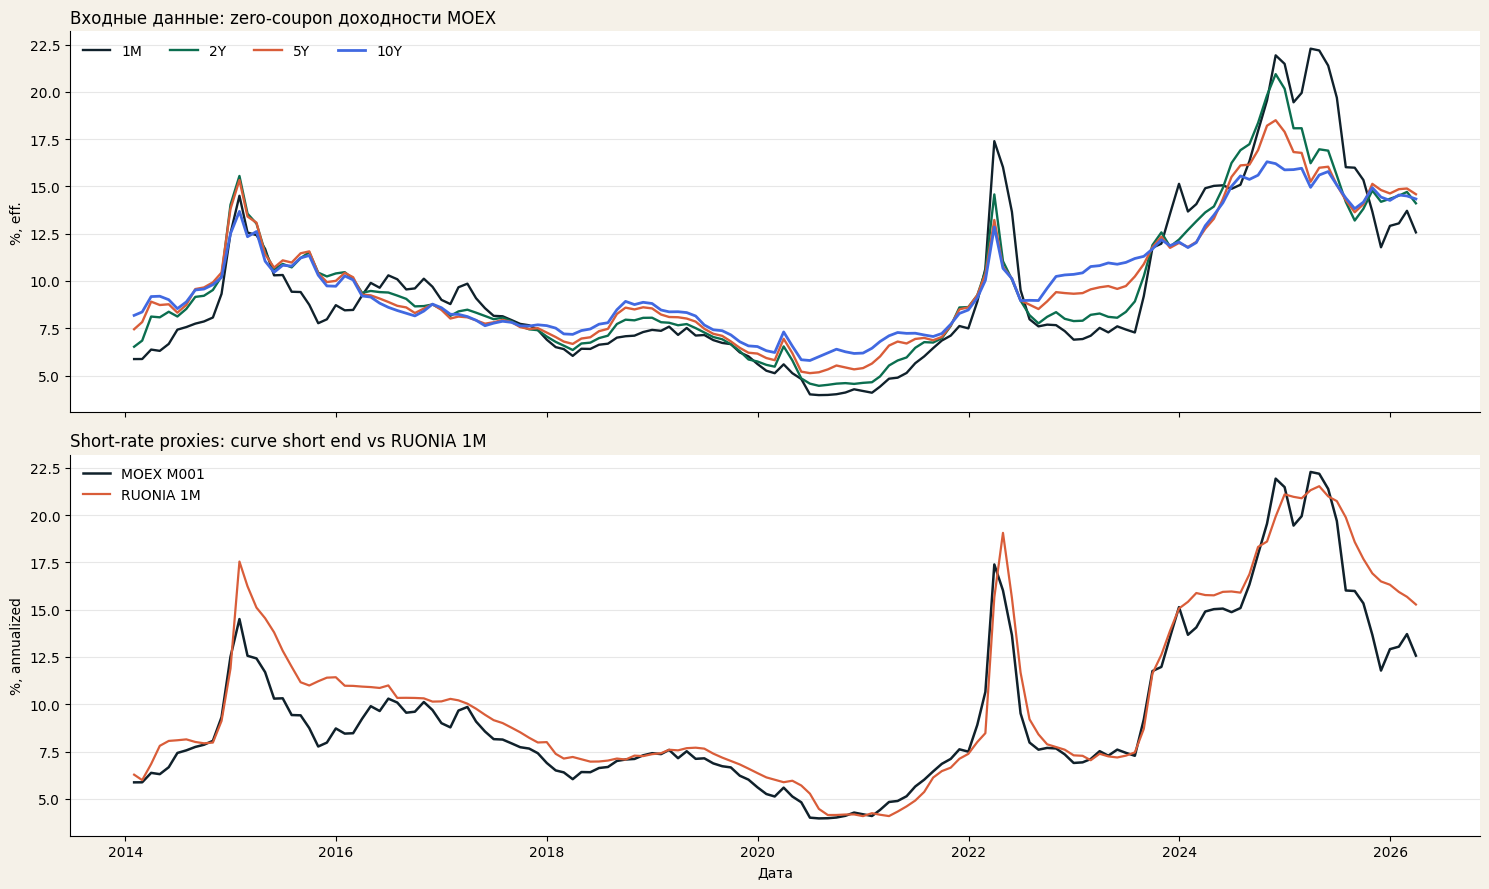

In [15]:
import matplotlib.pyplot as plt
import matplotlib.dates as mdates

presentation_curve = all_monthly_curve.copy()
presentation_curve['month_end'] = pd.to_datetime(presentation_curve['month_end'])

fig, axes = plt.subplots(2, 1, figsize=(15, 9), sharex=True, facecolor='#f5f1e8')

for month, label, color in [(1, '1M', '#10212b'), (24, '2Y', '#0b6e4f'), (60, '5Y', '#d95d39'), (120, '10Y', '#4169e1')]:
    axes[0].plot(presentation_curve['month_end'], presentation_curve[f'M{month:03d}'], lw=2 if month == 120 else 1.7, label=label, color=color)

axes[0].set_title('Входные данные: zero-coupon доходности MOEX', loc='left')
axes[0].set_ylabel('%, eff.')
axes[0].grid(True, axis='y', alpha=0.3)
axes[0].legend(ncol=4, frameon=False, loc='upper left')
axes[0].spines['top'].set_visible(False)
axes[0].spines['right'].set_visible(False)

short_rate_compare = all_monthly_curve[['month', 'month_end', 'M001']].merge(
    ruonia_monthly[['month', 'month_end', 'ruonia_1m_pct']],
    on=['month', 'month_end'],
    how='inner',
)
axes[1].plot(short_rate_compare['month_end'], short_rate_compare['M001'], label='MOEX M001', color='#10212b', lw=1.8)
axes[1].plot(short_rate_compare['month_end'], short_rate_compare['ruonia_1m_pct'], label='RUONIA 1M', color='#d95d39', lw=1.6)
axes[1].set_title('Short-rate proxies: curve short end vs RUONIA 1M', loc='left')
axes[1].set_ylabel('%, annualized')
axes[1].grid(True, axis='y', alpha=0.3)
axes[1].legend(frameon=False, loc='upper left')
axes[1].spines['top'].set_visible(False)
axes[1].spines['right'].set_visible(False)
axes[1].xaxis.set_major_locator(mdates.YearLocator(2))
axes[1].xaxis.set_major_formatter(mdates.DateFormatter('%Y'))
axes[1].set_xlabel('Дата')

fig.tight_layout()
plt.show()

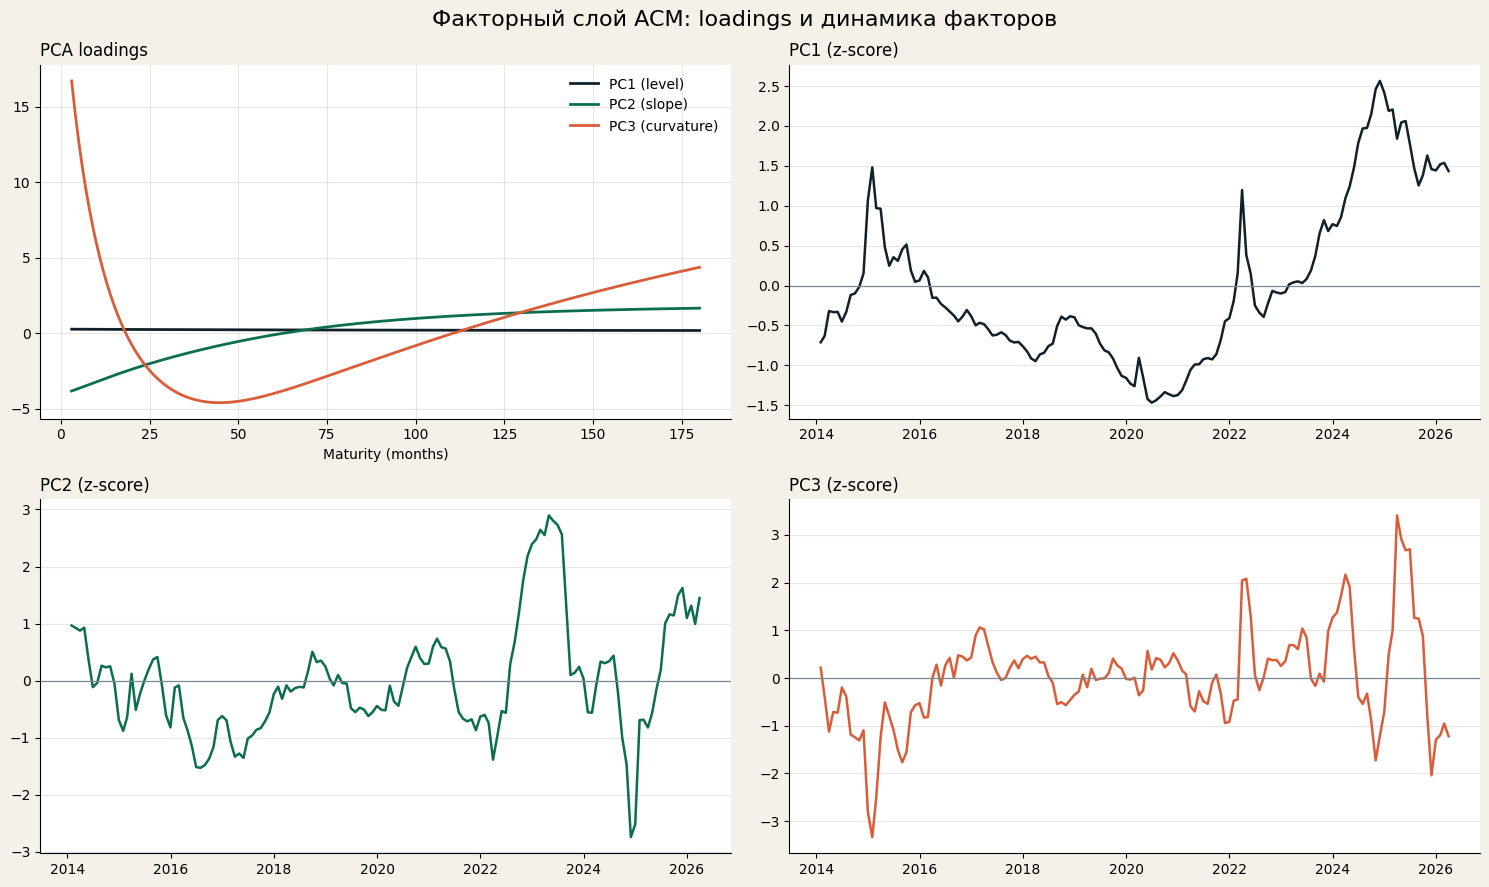

In [16]:
fig, axes = plt.subplots(2, 2, figsize=(15, 9), facecolor='#f5f1e8')

loadings_ax = axes[0, 0]
for column, label, color in [('PC 1', 'PC1 (level)', '#10212b'), ('PC 2', 'PC2 (slope)', '#0b6e4f'), ('PC 3', 'PC3 (curvature)', '#d95d39')]:
    loadings_ax.plot(acm.pc_loadings_m.index, acm.pc_loadings_m[column], lw=2, label=label, color=color)
loadings_ax.set_title('PCA loadings', loc='left')
loadings_ax.set_xlabel('Maturity (months)')
loadings_ax.grid(True, alpha=0.3)
loadings_ax.legend(frameon=False)
loadings_ax.spines['top'].set_visible(False)
loadings_ax.spines['right'].set_visible(False)

factor_df = scores.copy()
factor_df['month_end'] = pd.to_datetime(factor_df['month_end'])
for ax, pc, color in [(axes[0, 1], 'PC1', '#10212b'), (axes[1, 0], 'PC2', '#0b6e4f'), (axes[1, 1], 'PC3', '#d95d39')]:
    centered = (factor_df[pc] - factor_df[pc].mean()) / factor_df[pc].std(ddof=0)
    ax.plot(factor_df['month_end'], centered, color=color, lw=1.8)
    ax.axhline(0.0, color='#7a8890', lw=0.9)
    ax.set_title(f'{pc} (z-score)', loc='left')
    ax.grid(True, axis='y', alpha=0.3)
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)
    ax.xaxis.set_major_locator(mdates.YearLocator(2))
    ax.xaxis.set_major_formatter(mdates.DateFormatter('%Y'))

fig.suptitle('Факторный слой ACM: loadings и динамика факторов', fontsize=16, y=0.98)
fig.tight_layout()
plt.show()

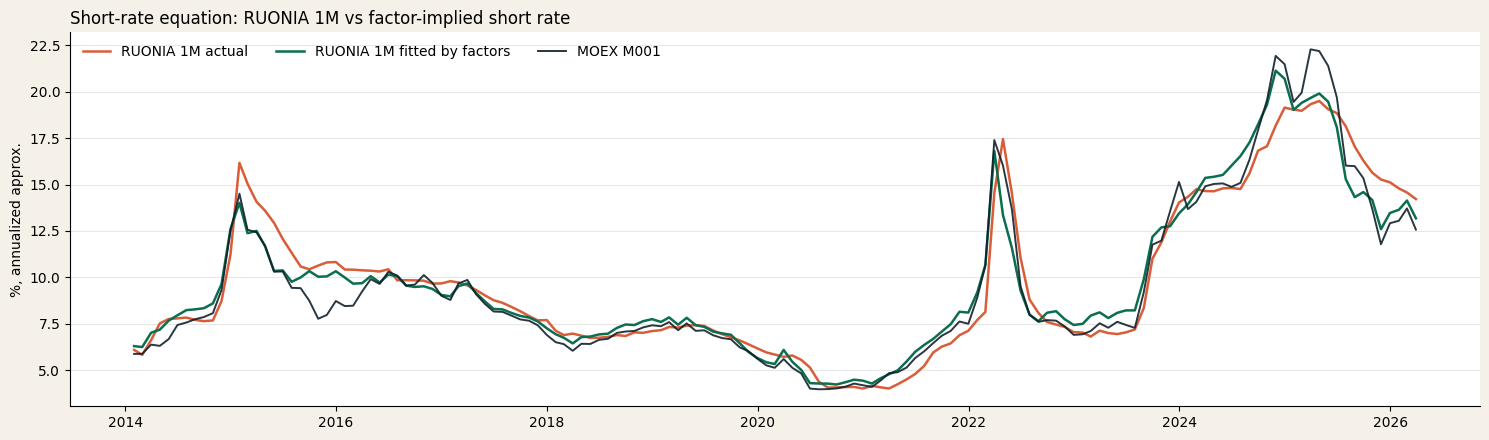

In [17]:
short_rate_sample_plot = short_rate_sample.copy()
short_rate_sample_plot['fitted_ruonia_cc_pct'] = short_rate_sample_plot[['PC1', 'PC2', 'PC3']].to_numpy(dtype=float) @ delta1_ruonia + delta0_ruonia
short_rate_sample_plot['fitted_ruonia_annual_cc_pct'] = short_rate_sample_plot['fitted_ruonia_cc_pct'] * 1200
short_rate_sample_plot['actual_ruonia_annual_cc_pct'] = short_rate_sample_plot['short_rate_monthly_cc'] * 1200
short_rate_sample_plot = short_rate_sample_plot.merge(
    all_monthly_curve[['month', 'month_end', 'M001']],
    on=['month', 'month_end'],
    how='left',
)

fig, ax = plt.subplots(figsize=(15, 4.5), facecolor='#f5f1e8')
ax.plot(short_rate_sample_plot['month_end'], short_rate_sample_plot['actual_ruonia_annual_cc_pct'], label='RUONIA 1M actual', color='#d95d39', lw=1.8)
ax.plot(short_rate_sample_plot['month_end'], short_rate_sample_plot['fitted_ruonia_annual_cc_pct'], label='RUONIA 1M fitted by factors', color='#0b6e4f', lw=1.8)
ax.plot(short_rate_sample_plot['month_end'], short_rate_sample_plot['M001'], label='MOEX M001', color='#10212b', lw=1.4, alpha=0.9)
ax.set_title('Short-rate equation: RUONIA 1M vs factor-implied short rate', loc='left')
ax.set_ylabel('%, annualized approx.')
ax.grid(True, axis='y', alpha=0.3)
ax.legend(frameon=False, ncol=3, loc='upper left')
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
ax.xaxis.set_major_locator(mdates.YearLocator(2))
ax.xaxis.set_major_formatter(mdates.DateFormatter('%Y'))
fig.tight_layout()
plt.show()

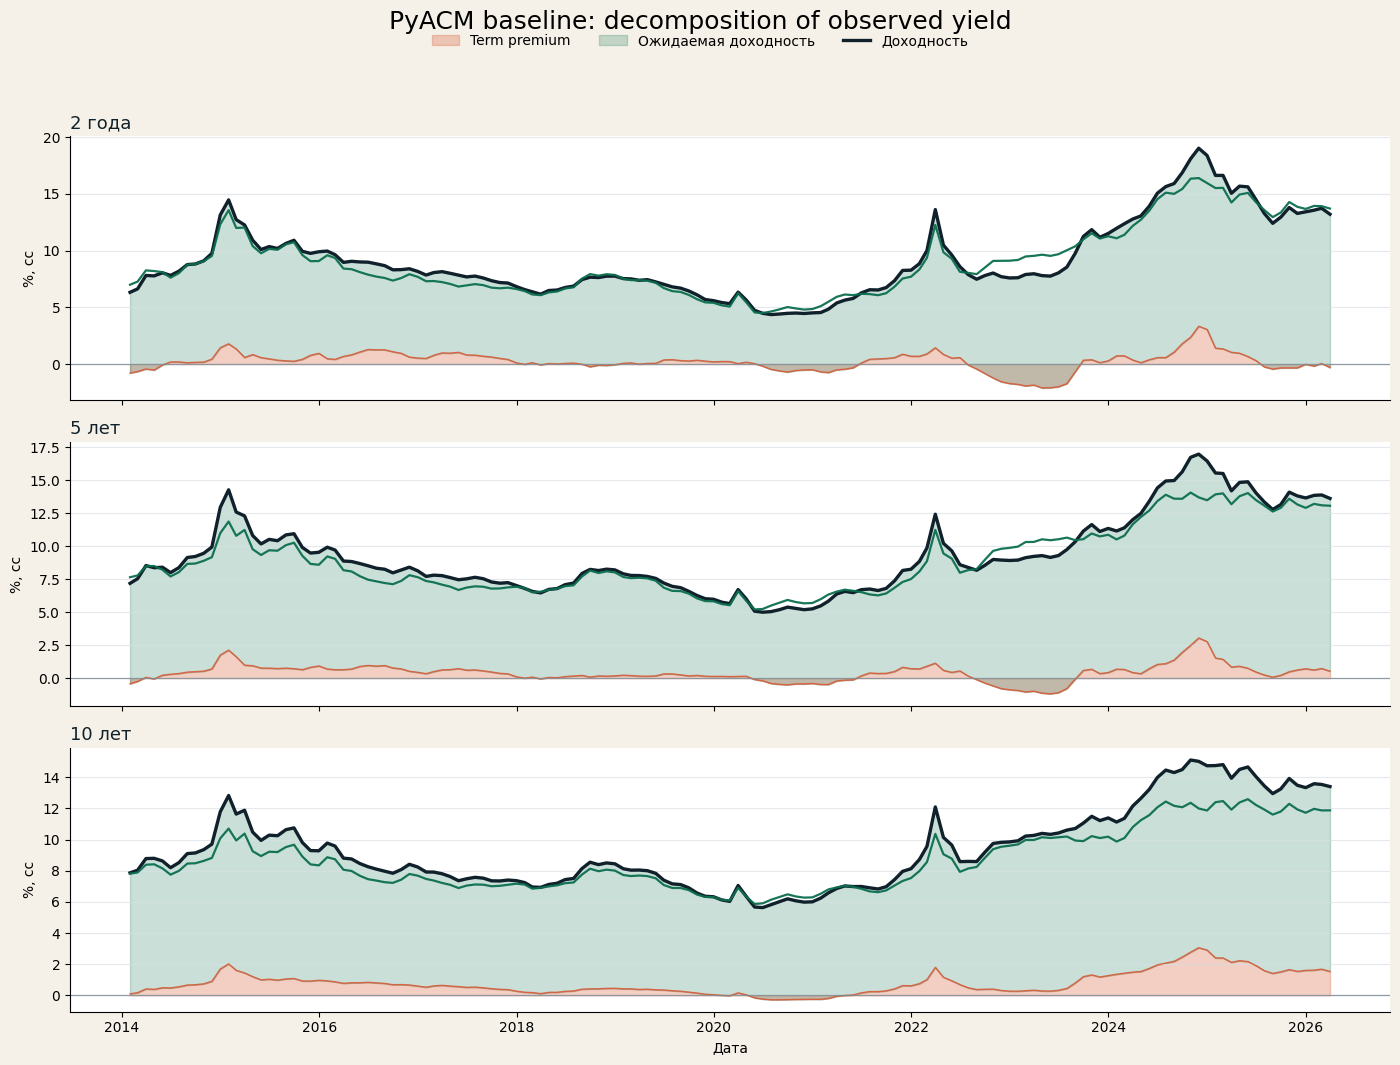

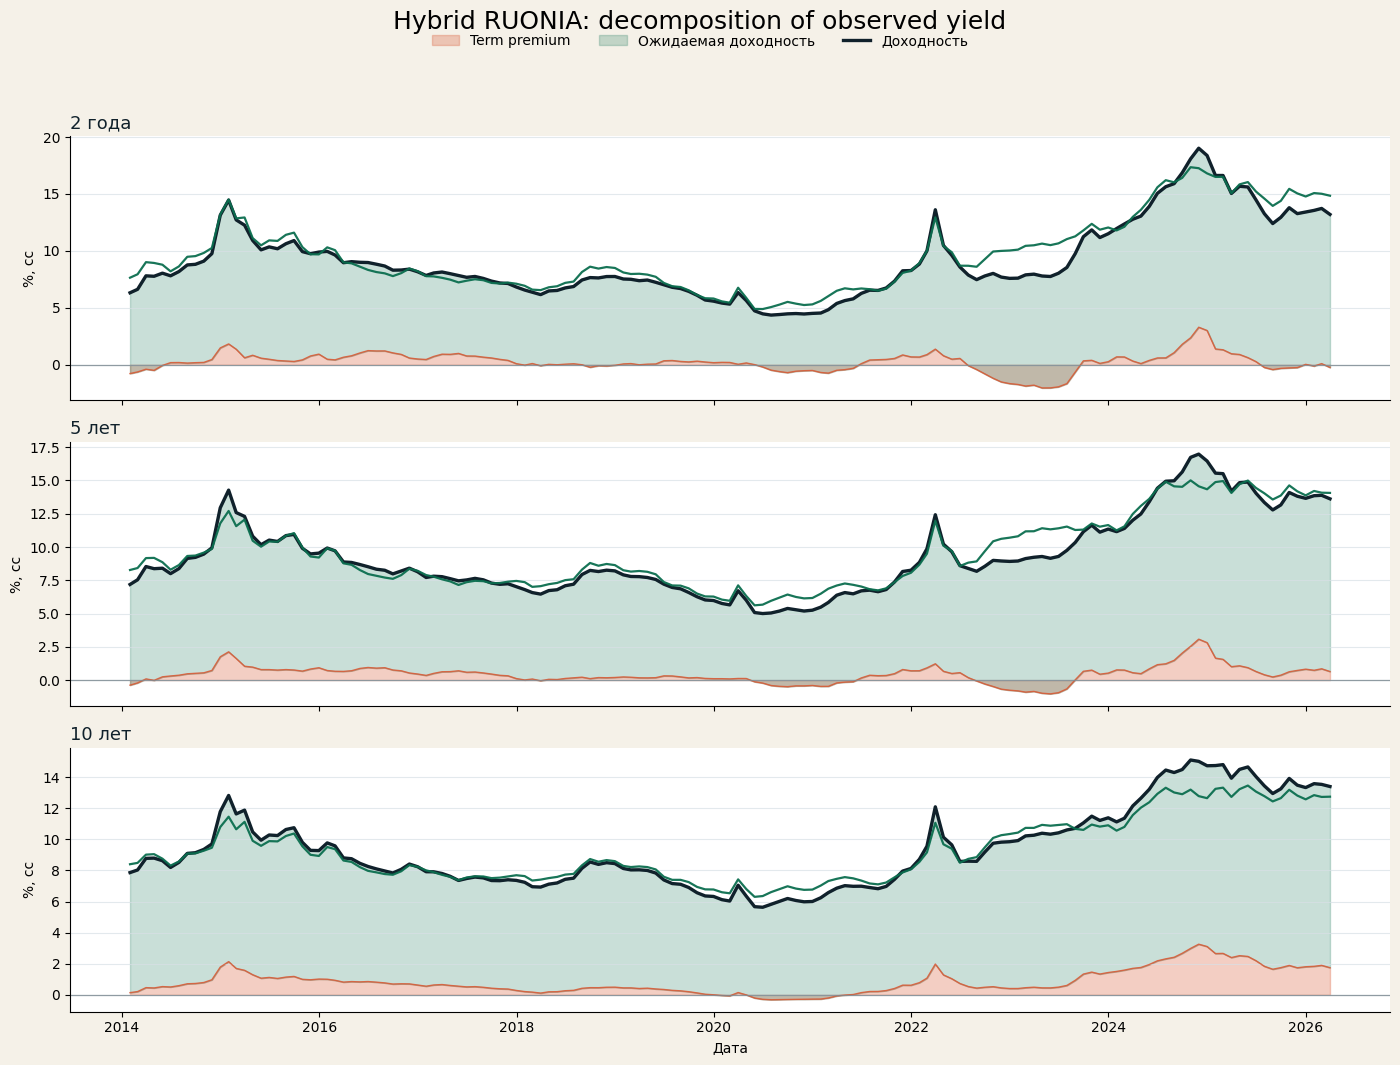

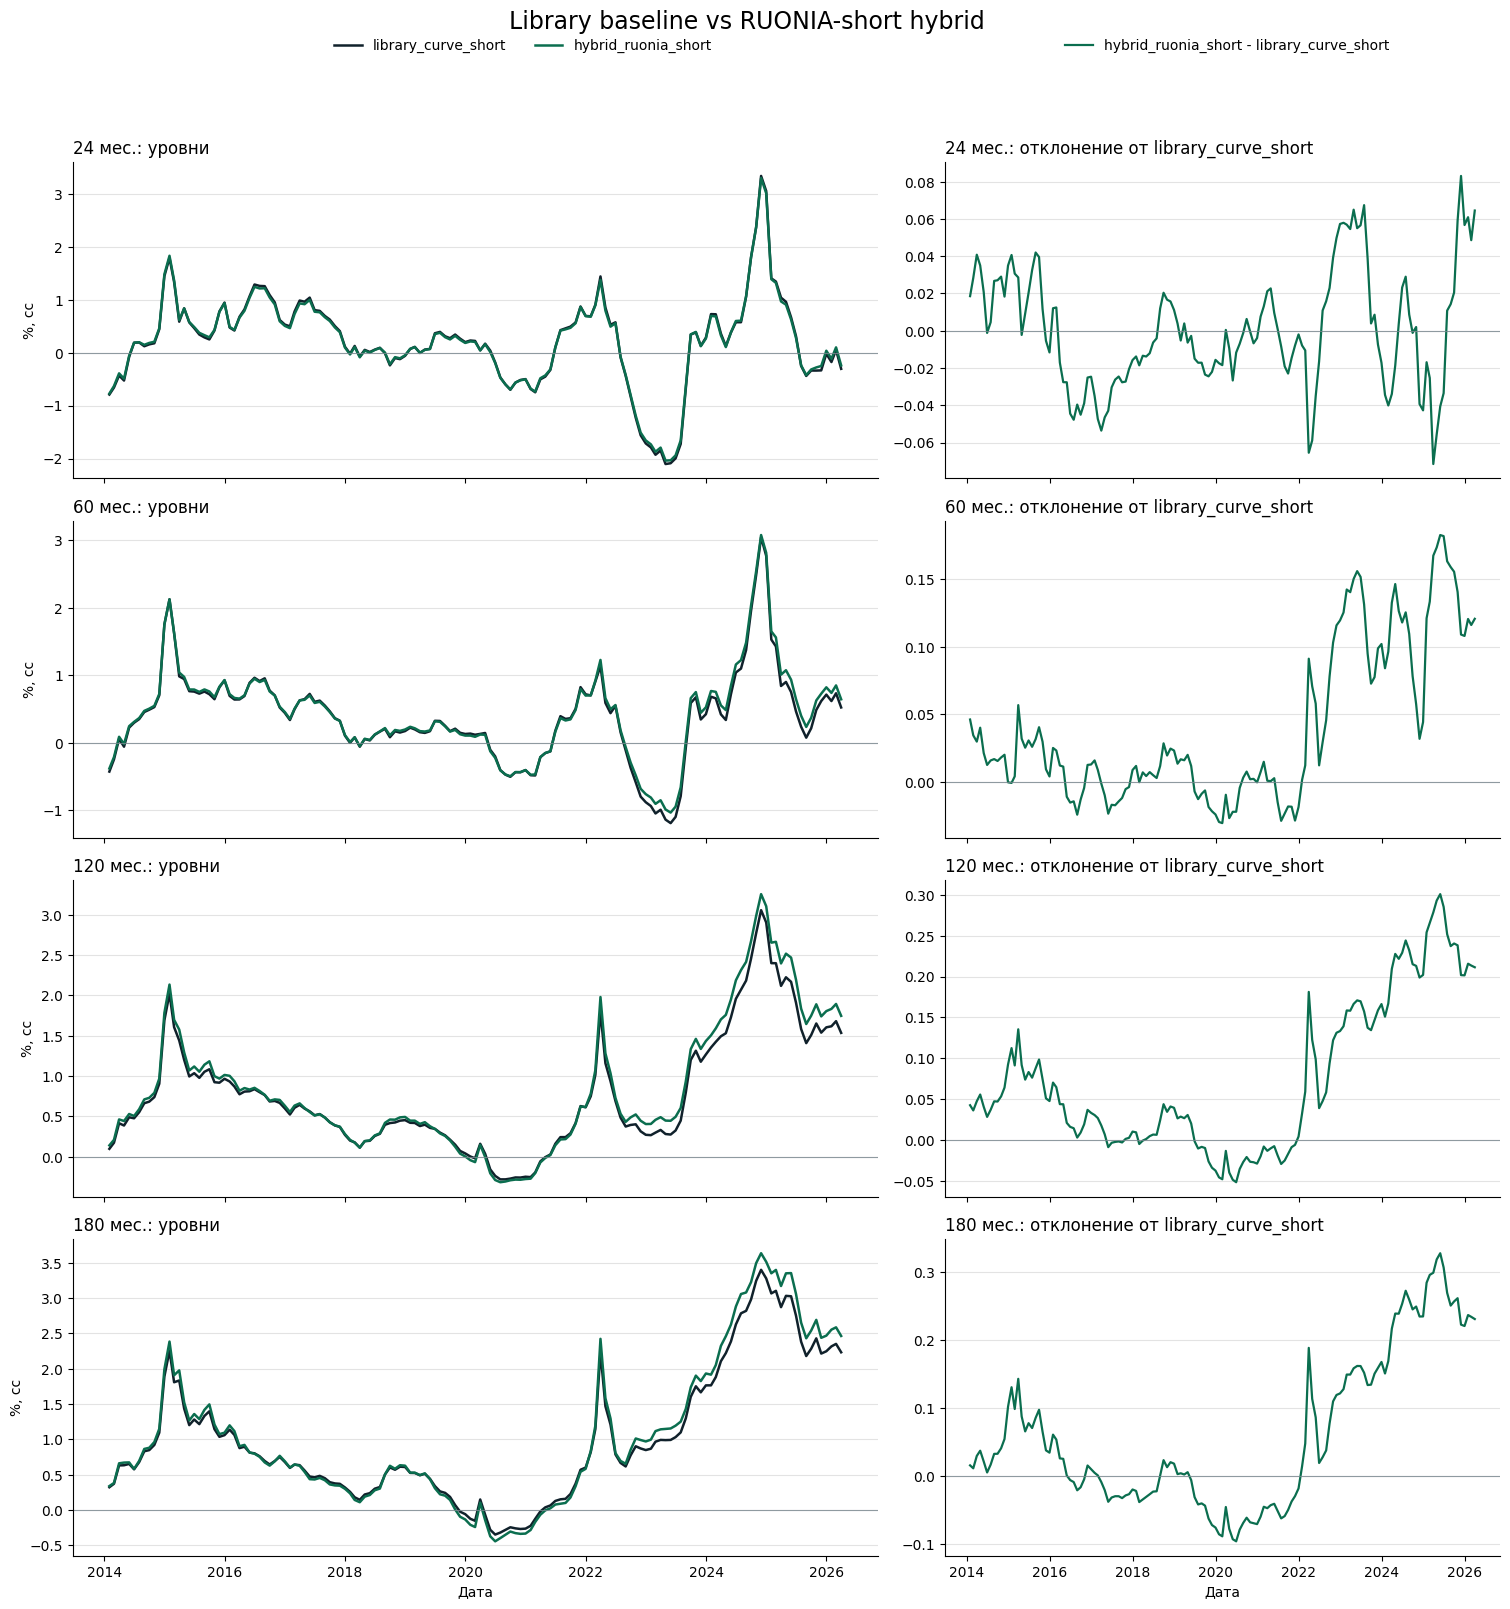

In [18]:
fig, axes = plot_term_premium_decomposition(
    term_premium_df=library_tp,
    tenors={24: '2 года', 60: '5 лет', 120: '10 лет'},
    title='PyACM baseline: decomposition of observed yield',
)
plt.show()

fig, axes = plot_term_premium_decomposition(
    term_premium_df=hybrid_tp,
    tenors={24: '2 года', 60: '5 лет', 120: '10 лет'},
    title='Hybrid RUONIA: decomposition of observed yield',
)
plt.show()

fig, axes = plot_term_premium_comparison(
    versions={
        'library_curve_short': library_tp,
        'hybrid_ruonia_short': hybrid_tp,
    },
    baseline='library_curve_short',
    tenors=(24, 60, 120, 180),
    title='Library baseline vs RUONIA-short hybrid',
)
plt.show()

/Users/codebuller/Desktop/term_rate/.venv/lib/python3.9/site-packages/pyacm/acm.py:155: FutureWarning: 'M' is deprecated and will be removed in a future version, please use 'ME' instead.
  self.curve_monthly = curve.resample('M').mean()
/var/folders/cj/d68fmsfj3jj2j09286d43rth0000gn/T/ipykernel_16259/1023967059.py:100: DeprecationWarning: Conversion of an array with ndim > 0 to a scalar is deprecated, and will error in future. Ensure you extract a single element from your array before performing this operation. (Deprecated NumPy 1.25.)
  a_fit[idx] = float(a_fit[idx - 1] + prev_fit @ (mu - lambda0)[:, 0] + s0term_fit + a_fit[0])
/var/folders/cj/d68fmsfj3jj2j09286d43rth0000gn/T/ipykernel_16259/1023967059.py:103: DeprecationWarning: Conversion of an array with ndim > 0 to a scalar is deprecated, and will error in future. Ensure you extract a single element from your array before performing this operation. (Deprecated NumPy 1.25.)
  a_rn[idx] = float(a_rn[idx - 1] + prev_rn @ mu[:, 0] + s

,sample,start,end,n_obs
0,full_history,2014-01-31,2026-03-31,147
1,article_like,2014-01-31,2024-05-31,125


,version,sample_end,tp_24_pct,tp_60_pct,tp_120_pct,tp_180_pct
0,library_full_at_article_end,2024-05-31,0.379,0.721,1.729,2.384
1,library_article_like,2024-05-31,1.073,2.352,3.623,4.083
2,hybrid_full_at_article_end,2024-05-31,0.383,0.847,1.950,2.623
3,hybrid_article_like,2024-05-31,1.173,2.557,3.911,4.356


,tenor_months,n_overlap,last_full_same_date_pct,last_article_pct,last_diff_pct,rmse_pct,mean_abs_diff_pct,corr
0,24,125,0.379,1.073,0.694,0.249,0.191,0.974
1,60,125,0.721,2.352,1.631,0.579,0.441,0.864
2,120,125,1.729,3.623,1.895,0.666,0.500,0.953
3,180,125,2.384,4.083,1.698,0.596,0.444,0.990


,tenor_months,n_overlap,last_full_same_date_pct,last_article_pct,last_diff_pct,rmse_pct,mean_abs_diff_pct,corr
0,24,125,0.383,1.173,0.791,0.315,0.235,0.972
1,60,125,0.847,2.557,1.710,0.629,0.477,0.891
2,120,125,1.950,3.911,1.961,0.684,0.520,0.973
3,180,125,2.623,4.356,1.733,0.597,0.453,0.995


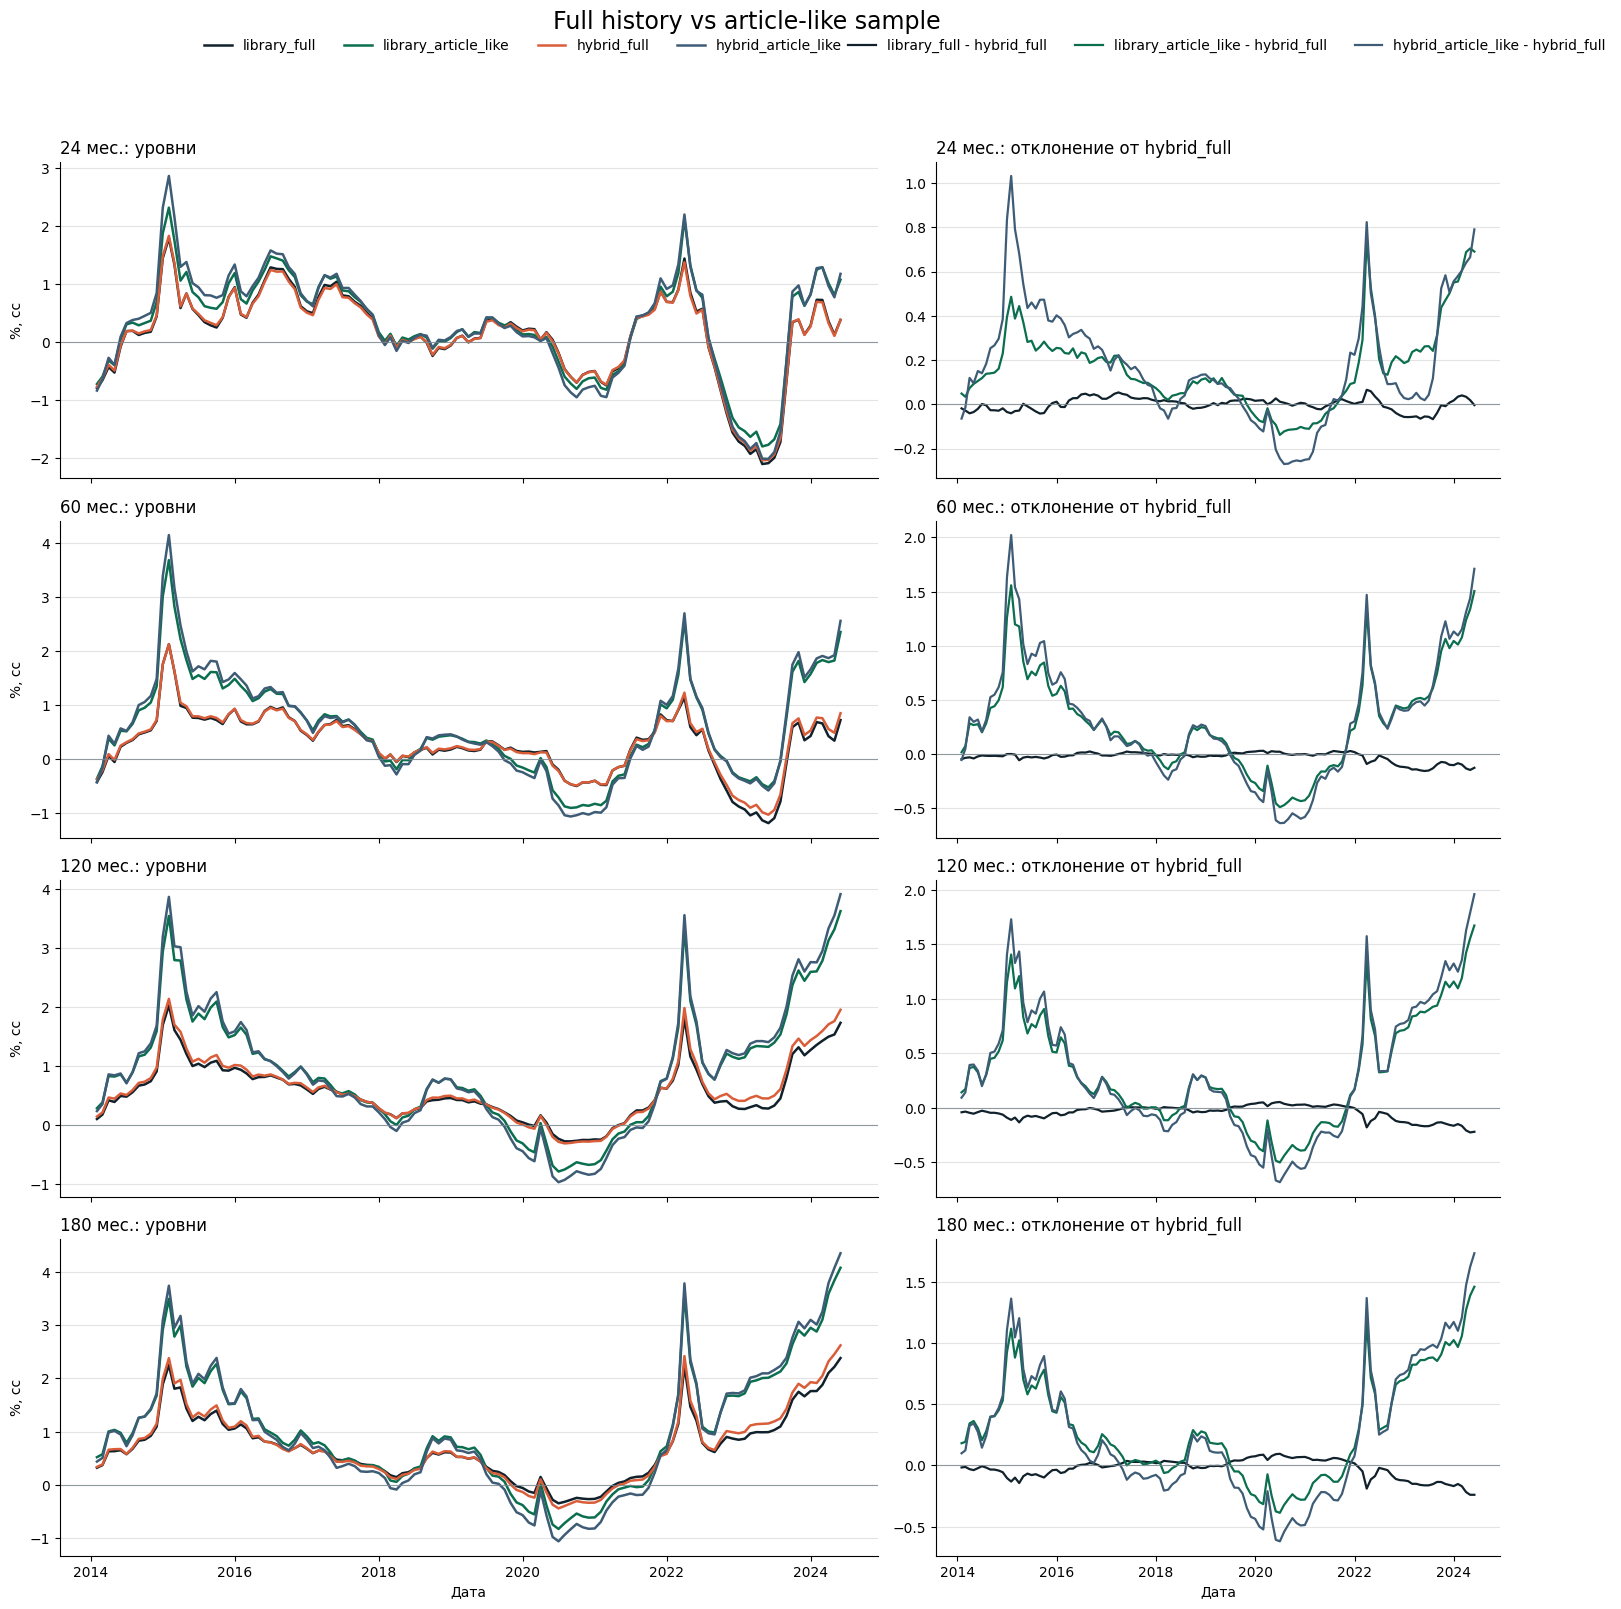

In [19]:
ARTICLE_START = pd.Timestamp('2014-01-31')
ARTICLE_END = pd.Timestamp('2024-05-31')
ARTICLE_TENORS = (24, 60, 120, 180)

article_monthly_curve = all_monthly_curve.loc[
    all_monthly_curve['month_end'].between(ARTICLE_START, ARTICLE_END)
].copy()
article_ruonia_monthly = ruonia_monthly.loc[
    ruonia_monthly['month_end'].between(ARTICLE_START, ARTICLE_END)
].copy()

article_yield_curve = to_pyacm_curve(article_monthly_curve)
article_acm = NominalACM(curve=article_yield_curve, n_factors=3)
article_scores = make_library_scores(article_acm)
article_library_tp = build_library_term_premium_frame(article_acm)
article_delta0_ruonia, article_delta1_ruonia, article_short_rate_sample, article_short_rate_params = fit_short_rate_ruonia(
    article_scores,
    article_ruonia_monthly,
)
article_hybrid_tp = build_hybrid_term_premium(
    acm=article_acm,
    delta0=article_delta0_ruonia,
    delta1=article_delta1_ruonia,
)

def compare_sample_to_full(full_df: pd.DataFrame, sample_df: pd.DataFrame, tenors=ARTICLE_TENORS) -> pd.DataFrame:
    cols = [f'tp_M{tenor:03d}' for tenor in tenors]
    merged = full_df[['date', *cols]].merge(sample_df[['date', *cols]], on='date', suffixes=('_full', '_article'))
    rows = []
    for tenor in tenors:
        col = f'tp_M{tenor:03d}'
        full_col = f'{col}_full'
        article_col = f'{col}_article'
        diff = merged[article_col] - merged[full_col]
        rows.append(
            {
                'tenor_months': tenor,
                'n_overlap': len(merged),
                'last_full_same_date_pct': merged[full_col].iloc[-1],
                'last_article_pct': merged[article_col].iloc[-1],
                'last_diff_pct': diff.iloc[-1],
                'rmse_pct': float(np.sqrt(np.mean(np.square(diff)))),
                'mean_abs_diff_pct': float(np.mean(np.abs(diff))),
                'corr': float(merged[full_col].corr(merged[article_col])),
            }
        )
    return pd.DataFrame(rows)

def values_on_date(term_premium_df: pd.DataFrame, date: pd.Timestamp, tenors=ARTICLE_TENORS) -> dict[str, float]:
    row = term_premium_df.loc[term_premium_df['date'] == date].iloc[0]
    return {f'tp_{tenor}_pct': row[f'tp_M{tenor:03d}'] for tenor in tenors}

article_window_summary = pd.DataFrame(
    {
        'sample': ['full_history', 'article_like'],
        'start': [library_tp['date'].min(), article_library_tp['date'].min()],
        'end': [library_tp['date'].max(), article_library_tp['date'].max()],
        'n_obs': [len(library_tp), len(article_library_tp)],
    }
)

article_end_date = article_library_tp['date'].iloc[-1]
same_date_comparison = pd.DataFrame(
    [
        {
            'version': 'library_full_at_article_end',
            'sample_end': article_end_date,
            **values_on_date(library_tp, article_end_date),
        },
        {
            'version': 'library_article_like',
            'sample_end': article_end_date,
            **values_on_date(article_library_tp, article_end_date),
        },
        {
            'version': 'hybrid_full_at_article_end',
            'sample_end': article_end_date,
            **values_on_date(hybrid_tp, article_end_date),
        },
        {
            'version': 'hybrid_article_like',
            'sample_end': article_end_date,
            **values_on_date(article_hybrid_tp, article_end_date),
        },
    ]
)

article_library_vs_full = compare_sample_to_full(library_tp, article_library_tp)
article_hybrid_vs_full = compare_sample_to_full(hybrid_tp, article_hybrid_tp)

display(article_window_summary)
display(same_date_comparison.round(3))
display(article_library_vs_full.round(3))
display(article_hybrid_vs_full.round(3))

fig, axes = plot_term_premium_comparison(
    versions={
        'library_full': library_tp,
        'library_article_like': article_library_tp,
        'hybrid_full': hybrid_tp,
        'hybrid_article_like': article_hybrid_tp,
    },
    baseline='hybrid_full',
    tenors=ARTICLE_TENORS,
    title='Full history vs article-like sample',
)
plt.show()

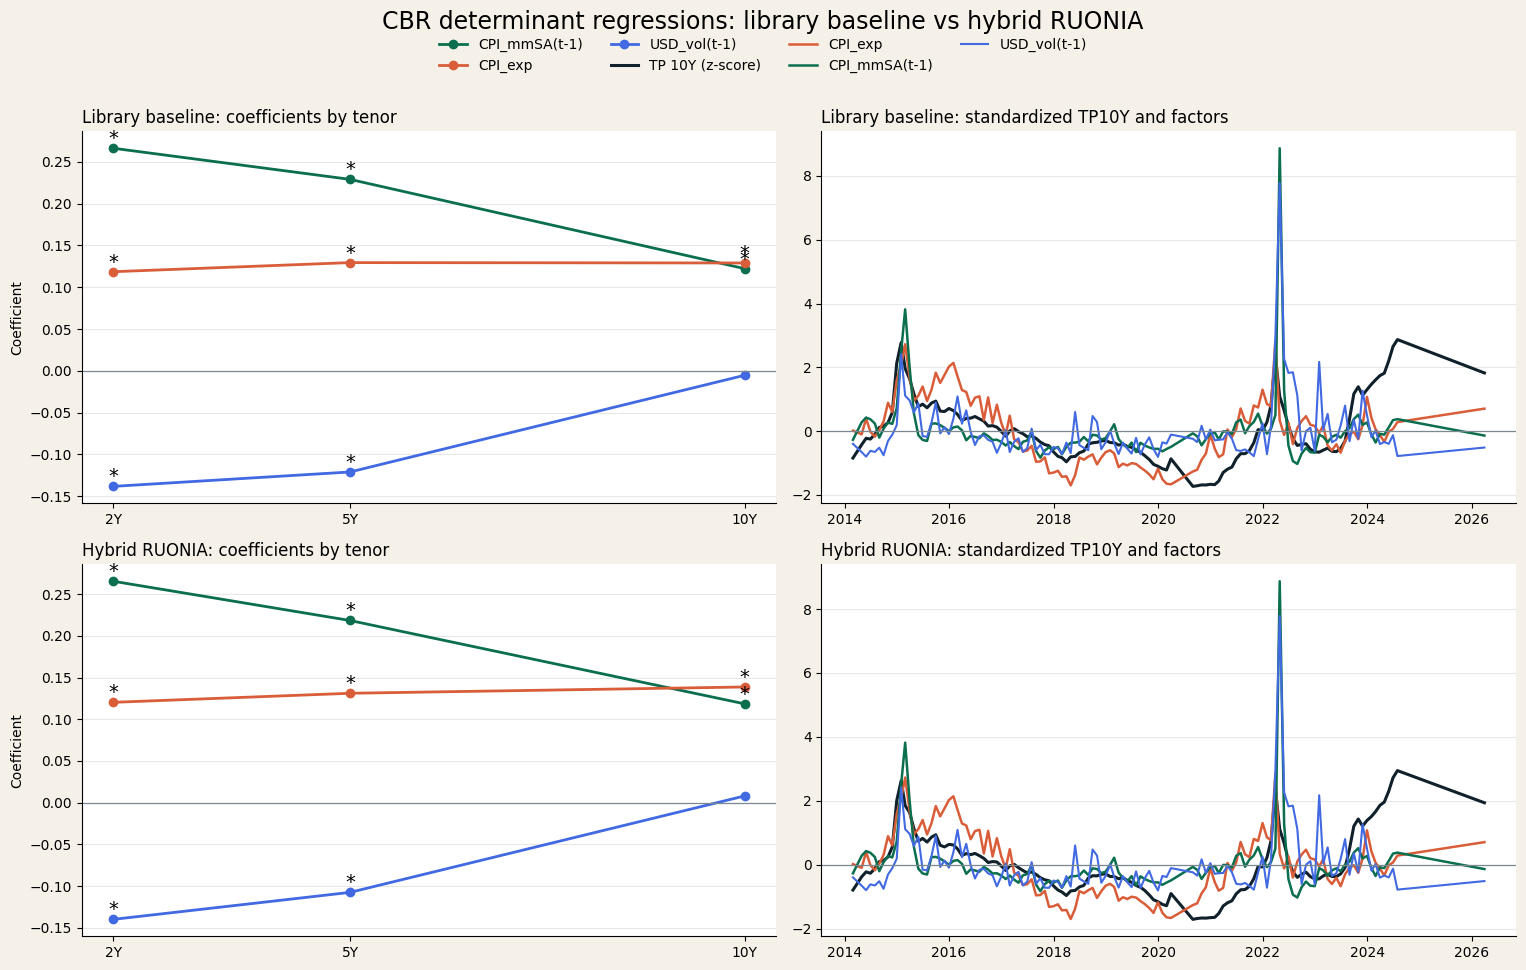

In [20]:
from cbr_determinants import plot_tp_determinant_regressions

fig, axes = plot_tp_determinant_regressions(
    determinant_results=determinant_results,
    model_samples={
        'library': library_det_sample,
        'hybrid_ruonia': hybrid_det_sample,
    },
)
plt.show()

spec                        cpi_exp_pct  cpi_mmsa_lag1  full_model  \
model         tenor_months                                           
hybrid_ruonia 24                  0.158          0.062       0.194   
              60                  0.341          0.115       0.385   
              120                 0.405          0.148       0.433   
library       24                  0.147          0.059       0.181   
              60                  0.310          0.103       0.357   
              120                 0.422          0.153       0.451   

spec                        usd_vol_lag1  
model         tenor_months                
hybrid_ruonia 24                   0.010  
              60                   0.030  
              120                  0.106  
library       24                   0.010  
              60                   0.022  
              120                  0.100

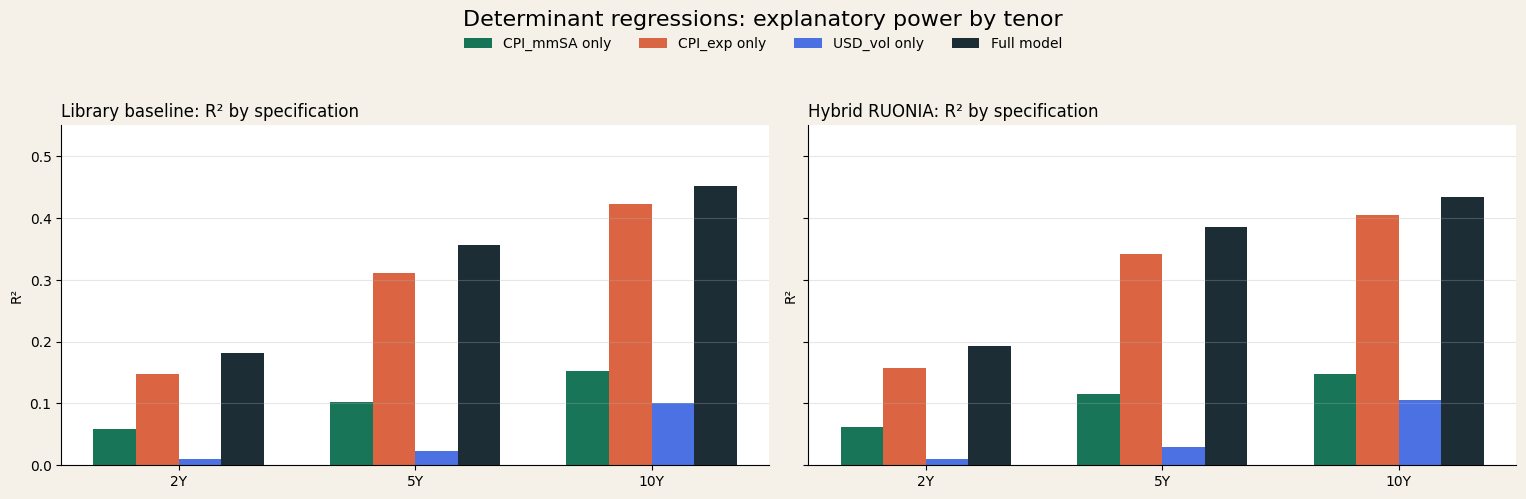

In [21]:
from cbr_determinants import compute_determinant_r2_summary, plot_determinant_r2_summary

library_r2 = compute_determinant_r2_summary(library_tp, observed_factors)
library_r2.insert(0, 'model', 'library')
hybrid_r2 = compute_determinant_r2_summary(hybrid_tp, observed_factors)
hybrid_r2.insert(0, 'model', 'hybrid_ruonia')
r2_summary = pd.concat([library_r2, hybrid_r2], ignore_index=True)
display(r2_summary.pivot_table(index=['model', 'tenor_months'], columns='spec', values='r2').round(3))

fig, axes = plot_determinant_r2_summary(r2_summary)
plt.show()